# 项目简介

Kaggle地址:https://www.kaggle.com/blastchar/telco-customer-churn


> **About Dataset**  
> *Context*
> "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]
> 
> *Content*
> Each row represents a customer, each column contains customer’s attributes described on the column Metadata.
> 
> **The data set includes information about**:
> 
> + Customers who left within the last month – the column is called Churn
> + Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
> + Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
> + Demographic info about customers – gender, age range, and if they have partners and dependents
> 
> *Inspiration*
> To explore this type of models and learn more about the subject.   
> 
> New version from IBM:
> https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113

# Imports

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
import plotly.graph_objects as go
import plotly.express as px

In [201]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, f1_score, auc

In [195]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [196]:
import xgboost as xgb
from xgboost import XGBClassifier

In [198]:
from optuna import create_study
from optuna.trial import Trial

In [26]:
# 设置显示所有的列
pd.options.display.max_columns = None

# Common-Functions

In [30]:
def missing_summary(df: pd.DataFrame, only_miss: bool = True):
    """
    用于统计DF中各列的缺失值信息和占比。
    only_miss: 是否返回所有的列，False只返回有缺失值的列
    """
    # df.isnull()，此方法是 DataFrame.isna 的别名，返回一个和原始 df shape 一样的DataFrame，元素为bool类型，True表示对应位置为缺失值
    miss_num = df.isnull().sum()   # 等价于sum(axis=0)
    if only_miss:  # 只展示有缺失值的特征
        miss_num = miss_num[miss_num > 0]
    # 总样本量
    total = df.shape[0]
    # 缺失值占比（%）
    miss_percent = miss_num / total * 100
    # 各个特征的取值
    cols_values = pd.Series({col: df[col].unique() for col in df})
    # 汇总信息
    miss_info = pd.concat(
        objs=[miss_num, miss_percent, df.dtypes, cols_values],
        axis=1, keys=['miss_num', 'miss_percent', 'dtype', 'values']
    )
    # 统计各个特征的取值个数
    miss_info['values_cnt'] = miss_info['values'].apply(len)
    miss_info['total'] = total
    miss_info = miss_info[['miss_num', 'total', 'miss_percent', 'dtype', 'values_cnt', 'values']]
    miss_info.dropna(inplace=True)
    # 降序排列，同时设置小数点的位数
    miss_info = miss_info.sort_values(by=['miss_num'], ascending=False).round(decimals=3)
    return miss_info

---
# EDA

## 数据加载

In [4]:
%pwd

'C:\\Users\\Drivi\\Python-Projects\\DataAnalysis\\Projects-in-Action\\Telco-Customer-Churn'

In [5]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.shape

(7043, 21)

In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 特征介绍

| 字段 | 解释 |
| ------ | ------ |
| customerID | 用户ID |
| gender | 性别 |
| SeniorCitizen | 是否是老年人（1代表是） |
| Partner | 是否有配偶（Yes or No） |
| Dependents | 是否经济独立（Yes or No） |
| tenure | 用户入网时间 |
| PhoneService | 是否开通电话业务（Yes or No） |
| MultipleLines | 是否开通多条电话业务（Yes 、 No or No phoneservice） |
| InternetService | 是否开通互联网服务（No、DSL数字网络或filber potic光线网络） |
| OnlineSecurity | 是否开通网络安全服务（Yes、No or No internetservice） |
| OnlineBackup | 是否开通在线备份服务（Yes、No or No internetservice） |
| DeviceProtection | 是否开通设备保护服务（Yes、No or No internetservice） |
| TechSupport | 是否开通技术支持业务（Yes、No or No internetservice）  |
| StreamingTV  | 是否开通网络电视（Yes、No or No internetservice） |
| StreamingMovies | 是否开通网络电影（Yes、No or No internetservice）  |
| Contract | 合同签订方式（按月、按年或者两年）  |
| PaperlessBilling | 是否开通电子账单（Yes or No）  |
| PaymentMethod | 付款方式（bank transfer、credit card、electronic check、mailed check） |
| MonthlyCharges | 月度费用 |
| TotalCharges | 总费用  |
| Churn | 是否流失（Yes or No） |

特征分为如下几类:

用户人口统计信息（4个）
+ gender，性别：Male/Female
+ SeniorCitizen，是否为老年人：0/1
+ Partner，是否有配偶：Yes/No
+ Dependents，是否有需要养育的人：Yes/No
  
用户注册的服务信息（9个）
+ PhoneService，是否注册了电话服务：Yes/No
+ MultipleLines，是否有多条线路服务：Yes/No/No phone service
+ InternetService，互联网服务提供商：DSL/Fiber optic/No
+ OnlineSecurity，是否登记了在线安全服务：Yes/No/No inernet service
+ OnlineBackup，是否有备份线路：Yes/No/No inernet service
+ DeviceProtection，是否登记了设备保护服务：Yes/No/No inernet service
+ TechSupport，是否登记了技术支持服务：Yes/No/No inernet service
+ StreamingTV，是否登记了流媒体电视服务：Yes/No/No inernet service
+ StreamingMovies，是否登记了流媒体电影服务：Yes/No/No inernet service


用户账户信息（6个）  
+ tenure，任职时长，单位为月
+ Contract，合同类型：Month-to-month/One year/Two year
+ PaperlessBilling，是否开通电子账单：Yes/No
+ PaymentMethod，支付方式：Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)
+ MonthlyCharges，每月账单
+ TotalCharges，总账单

目标变量（1个）
+ Churn，是否流失：Yes/No

## 缺失值检查

In [31]:
miss_df = missing_summary(data, only_miss=False)
miss_df

,miss_num,total,miss_percent,dtype,values_cnt,values
customerID,0,7043,0.0,object,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,0,7043,0.0,object,2,"[Female, Male]"
SeniorCitizen,0,7043,0.0,int64,2,"[0, 1]"
Partner,0,7043,0.0,object,2,"[Yes, No]"
Dependents,0,7043,0.0,object,2,"[No, Yes]"
tenure,0,7043,0.0,int64,73,"[1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ..."
PhoneService,0,7043,0.0,object,2,"[No, Yes]"
MultipleLines,0,7043,0.0,object,3,"[No phone service, No, Yes]"
InternetService,0,7043,0.0,object,3,"[DSL, Fiber optic, No]"
OnlineSecurity,0,7043,0.0,object,3,"[No, Yes, No internet service]"


上面看起来没有缺失值，但是TotalCharges这个特征是object而不是float，需要检查

In [37]:
# 注意TotalCharges这个特征是字符类型，需要转成float
# 但是转换的时候会报错，需要检查
# data['TotalCharges'].astype(np.float)
error_index = []
for index, value in data['TotalCharges'].items():
    try:
        float(value)
    except ValueError:
        error_index.append(index)
        print(f"cast error at index: {index}, value: {value}")

cast error at index: 488, value: 
cast error at index: 753, value: 
cast error at index: 936, value: 
cast error at index: 1082, value: 
cast error at index: 1340, value: 
cast error at index: 3331, value: 
cast error at index: 3826, value: 
cast error at index: 4380, value: 
cast error at index: 5218, value: 
cast error at index: 6670, value: 
cast error at index: 6754, value: 


totalcharges在上述行的值是空的，但是并没有显示为null，实际上这是一个空格，长度为1。

可以通过字符串的`strip`方法去除掉，也可以直接置为null。

In [40]:
# 去除掉空格然后再检查是否有缺失值
# data['TotalCharges'] = data['TotalCharges'].str.strip()
# 这里选择直接置为null
data.loc[error_index, 'TotalCharges'] = np.nan

In [41]:
# 再次检查缺失值
miss_df = missing_summary(data, only_miss=False)
miss_df

,miss_num,total,miss_percent,dtype,values_cnt,values
TotalCharges,11,7043,0.156,object,6531,"[29.85, 1889.5, 108.15, 1840.75, 151.65, 820.5..."
gender,0,7043,0.000,object,2,"[Female, Male]"
SeniorCitizen,0,7043,0.000,int64,2,"[0, 1]"
Partner,0,7043,0.000,object,2,"[Yes, No]"
customerID,0,7043,0.000,object,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
Dependents,0,7043,0.000,object,2,"[No, Yes]"
tenure,0,7043,0.000,int64,73,"[1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ..."
MultipleLines,0,7043,0.000,object,3,"[No phone service, No, Yes]"
PhoneService,0,7043,0.000,object,2,"[No, Yes]"
OnlineSecurity,0,7043,0.000,object,3,"[No, Yes, No internet service]"


In [58]:
# 先转成float，再用 0 填充
data['TotalCharges'] = data['TotalCharges'].astype(dtype=float, copy=True)

In [59]:
data['TotalCharges'].fillna(value=0, inplace=True)

C:\Users\Drivi\AppData\Local\Temp\ipykernel_35252\4049028933.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(value=0, inplace=True)


## 可视化分析

检查类别的平衡

In [72]:
# print(type(data['Churn'].value_counts()))
cls_cnt = data['Churn'].value_counts()
cls_cnt

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

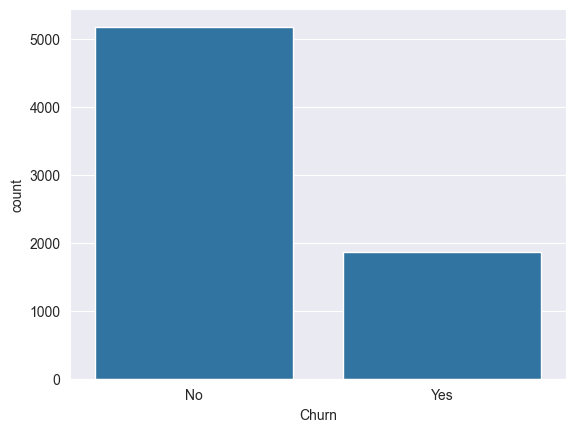

In [82]:
# seaborn没有饼图，所以绘制直方图
sns.countplot(data=data, x='Churn', legend='full')

In [83]:
# plotly绘图
# px.pie(data_frame=cls_cnt, values=cls_cnt, names=cls_cnt.index, title="类别Churn的分布")
# trace = go.Pie(values=cls_cnt, labels=cls_cnt.index, name='class_cnt', title='类别Churn的分布')
# fig = go.Figure(trace)
# fig.show(browser='edge')

## 数据集划分

In [183]:
# 这里使用 stratify 参数保证划分后类别的比例保持一致
data_train, data_test = train_test_split(data, test_size=0.2, random_state=29, stratify=data['Churn'])

In [184]:
print("data_train.shape: ", data_train.shape, "; data_test.shape: ", data_test.shape)

data_train.shape:  (5634, 21) ; data_test.shape:  (1409, 21)


In [185]:
data_train['Churn'].value_counts(normalize=True)

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

In [186]:
data_test['Churn'].value_counts(normalize=True)

Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64

---
# 特征工程

In [85]:
miss_df

,miss_num,total,miss_percent,dtype,values_cnt,values
TotalCharges,11,7043,0.156,object,6531,"[29.85, 1889.5, 108.15, 1840.75, 151.65, 820.5..."
gender,0,7043,0.000,object,2,"[Female, Male]"
SeniorCitizen,0,7043,0.000,int64,2,"[0, 1]"
Partner,0,7043,0.000,object,2,"[Yes, No]"
customerID,0,7043,0.000,object,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
Dependents,0,7043,0.000,object,2,"[No, Yes]"
tenure,0,7043,0.000,int64,73,"[1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ..."
MultipleLines,0,7043,0.000,object,3,"[No phone service, No, Yes]"
PhoneService,0,7043,0.000,object,2,"[No, Yes]"
OnlineSecurity,0,7043,0.000,object,3,"[No, Yes, No internet service]"


其中 customerID 在我看来是个无效的特征，不予理会，实际有用的特征只有 19 个。

In [99]:
# 类别特征
cat_columns = [
    'gender', 'Partner', 'Dependents', 'MultipleLines', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'InternetService', 'TechSupport', 'StreamingTV', 'Contract', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod'
]

In [100]:
# 数值特征
num_columns = ['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges']

In [127]:
print(f'len(cat_columns): {len(cat_columns)}, len(num_columns): {len(num_columns)}, total: {len(cat_columns) + len(num_columns)}')

len(cat_columns): 15, len(num_columns): 4, total: 19


## 类别变量处理

这里不使用 pd.get_dummies()，而是使用 sklearn.preprocessing.OneHotEncoder.

In [111]:
ONEHOT_FEATURE_NAME_MAP = {
    'MultipleLines': {'No phone service': 'NoService'},
    'OnlineSecurity': {'No internet service': 'NoService'},
    'OnlineBackup': {'No internet service': 'NoService'},
    'DeviceProtection': {'No internet service': 'NoService'},
    'InternetService': {'Fiber optic': 'FiberOptic'},
    'TechSupport': {'No internet service': 'NoService'},
    'StreamingTV': {'No internet service': 'NoService'},
    'Contract': {'Month-to-month': 'Month', 'One year': 'OneYear', 'Two year': 'TwoYear'},
    'StreamingMovies': {'No internet service': 'NoService'},
    'PaymentMethod': {
        'Electronic check': 'Electronic', 'Mailed check': 'Mailed', 
        'Bank transfer (automatic)': 'Bank', 'Credit card (automatic)': 'CreditCard'
    }
}

In [112]:
def onehot_feature_name_transform(input_feature: str, category: str) -> str:
    """ 返回一个类别特征对应的特征名 """
    if input_feature in ONEHOT_FEATURE_NAME_MAP and category in ONEHOT_FEATURE_NAME_MAP[input_feature]:
        category_value = ONEHOT_FEATURE_NAME_MAP[input_feature][category]
        return f'{input_feature}_{category_value}'
    return f'{input_feature}_{category}'

In [113]:
onehot_encoder = OneHotEncoder(sparse_output=False, drop='if_binary', feature_name_combiner=onehot_feature_name_transform)

In [114]:
onehot_encoder.fit(data[cat_columns])

OneHotEncoder(drop='if_binary',
              feature_name_combiner=<function onehot_feature_name_transform at 0x0000015F14BF3400>,
              sparse_output=False)

In [115]:
print(onehot_encoder.n_features_in_)
onehot_encoder.categories_

15


[array(['Female', 'Male'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'No phone service', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['DSL', 'Fiber optic', 'No'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Bank transfer (automatic)', 'Credit card (automatic)',
        'Electronic check', 'Mailed check'], dtype=object)]

In [126]:
onehot_encoder.get_feature_names_out()[:5]

array(['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'MultipleLines_No',
       'MultipleLines_NoService'], dtype=object)

In [105]:
t = onehot_encoder.transform(data[cat_columns])

In [117]:
type(t)

numpy.ndarray

In [118]:
t.shape

(7043, 36)

## 数值变量处理

In [130]:
# 查看一下数值特征的分位数信息
# data.describe([0.01, 0.25, 0.5, 0.75, 0.9, 1]).T
data[num_columns].describe([0.01, 0.25, 0.5, 0.75, 0.9, 1]).T

,count,mean,std,min,1%,25%,50%,75%,90%,100%,max
tenure,7043.0,32.371149,24.559481,0.00,1.00,9.00,29.00,55.00,69.00,72.00,72.00
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,19.20,35.50,70.35,89.85,102.60,118.75,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,19.75,398.55,1394.55,3786.60,5973.69,8684.80,8684.80


这里要注意，SeniorCitizen 其实应当视为类别变量。

由于 TotalCharges 数量级跨度比较大，所以做一下分箱处理。

In [133]:
kbins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans')
kbins.fit(data[['TotalCharges']])
kbins.bin_edges_

array([array([   0.        ,  597.23209504, 1359.2524906 , 2232.60104845,
              3213.014869  , 4177.57641146, 5082.764497  , 5898.06891255,
              6693.04916366, 7556.89725772, 8684.8       ])              ],
      dtype=object)

In [137]:
t = kbins.transform(data[['TotalCharges']])
t.shape

(7043, 1)

In [136]:
t[:5]

array([[0.],
       [2.],
       [0.],
       [2.],
       [0.]])

## 目标变量处理

In [120]:
# 需要将目标变量 Churn 从字符串转成 0-1, 使用LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(data['Churn'])

LabelEncoder()

In [121]:
label_encoder.classes_

array(['No', 'Yes'], dtype=object)

In [122]:
y = label_encoder.transform(data['Churn'])

In [125]:
y[:5]

array([0, 0, 1, 0, 1])

## 特征批量转换

In [151]:
cols_transformer = ColumnTransformer(
    transformers=[
        ('one_hot', onehot_encoder, cat_columns),
        ('kbins', kbins, ['TotalCharges'])
    ],
    remainder='passthrough',
    # 输出特征名称里，不需要转换器名称，下面两种方式都可以实现
    # verbose_feature_names_out='{feature_name}',
    verbose_feature_names_out=False,
    force_int_remainder_cols=False
)

In [152]:
cols_transformer.fit(data[cat_columns + num_columns])

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('one_hot',
                                 OneHotEncoder(drop='if_binary',
                                               feature_name_combiner=<function onehot_feature_name_transform at 0x0000015F14BF3400>,
                                               sparse_output=False),
                                 ['gender', 'Partner', 'Dependents',
                                  'MultipleLines', 'PhoneService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'InternetService',
                                  'TechSupport', 'StreamingTV', 'Contract',
                                  'StreamingMovies', 'PaperlessBilling',
                                  'PaymentMethod']),
                                ('kbins',
                                 KBinsDiscretizer(encode='ordinal', n_bins=10,
                                                  strategy='kmeans'),
                                 ['TotalCharges'])],
                  verbose_feature_names_out=False)

In [153]:
cols_transformer.transformers_

[('one_hot',
  OneHotEncoder(drop='if_binary',
                feature_name_combiner=<function onehot_feature_name_transform at 0x0000015F14BF3400>,
                sparse_output=False),
  ['gender',
   'Partner',
   'Dependents',
   'MultipleLines',
   'PhoneService',
   'OnlineSecurity',
   'OnlineBackup',
   'DeviceProtection',
   'InternetService',
   'TechSupport',
   'StreamingTV',
   'Contract',
   'StreamingMovies',
   'PaperlessBilling',
   'PaymentMethod']),
 ('kbins',
  KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='kmeans'),
  ['TotalCharges']),
 ('remainder',
  FunctionTransformer(accept_sparse=True, check_inverse=False,
                      feature_names_out='one-to-one'),
  ['tenure', 'SeniorCitizen', 'MonthlyCharges'])]

In [154]:
cols_transformer.get_feature_names_out()

array(['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'MultipleLines_No',
       'MultipleLines_NoService', 'MultipleLines_Yes', 'PhoneService_Yes',
       'OnlineSecurity_No', 'OnlineSecurity_NoService',
       'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_NoService',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_NoService', 'DeviceProtection_Yes',
       'InternetService_DSL', 'InternetService_FiberOptic',
       'InternetService_No', 'TechSupport_No', 'TechSupport_NoService',
       'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_NoService',
       'StreamingTV_Yes', 'Contract_Month', 'Contract_OneYear',
       'Contract_TwoYear', 'StreamingMovies_No',
       'StreamingMovies_NoService', 'StreamingMovies_Yes',
       'PaperlessBilling_Yes', 'PaymentMethod_Bank',
       'PaymentMethod_CreditCard', 'PaymentMethod_Electronic',
       'PaymentMethod_Mailed', 'TotalCharges', 'tenure', 'SeniorCitizen',
       'MonthlyCharges'], dtype=object)

注意，<font color="red">上面的特征转换使用 data 只是调试，下面需要分别使用 data_train, data_test。</font>

In [192]:
cols_transformer.fit(data_train[cat_columns + num_columns])

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('one_hot',
                                 OneHotEncoder(drop='if_binary',
                                               feature_name_combiner=<function onehot_feature_name_transform at 0x0000015F14BF3400>,
                                               sparse_output=False),
                                 ['gender', 'Partner', 'Dependents',
                                  'MultipleLines', 'PhoneService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'InternetService',
                                  'TechSupport', 'StreamingTV', 'Contract',
                                  'StreamingMovies', 'PaperlessBilling',
                                  'PaymentMethod']),
                                ('kbins',
                                 KBinsDiscretizer(encode='ordinal', n_bins=10,
                                                  strategy='kmeans'),
                                 ['TotalCharges'])],
                  verbose_feature_names_out=False)

In [187]:
# 训练集
X_transformed = cols_transformer.transform(data_train[cat_columns + num_columns])
X = pd.DataFrame(X_transformed, columns=cols_transformer.get_feature_names_out())

# 测试集
X_test_transformed = cols_transformer.transform(data_test[cat_columns + num_columns])
X_test = pd.DataFrame(X_test_transformed, columns=cols_transformer.get_feature_names_out())

In [190]:
y = label_encoder.transform(data_train['Churn'])
y_test = label_encoder.transform(data_test['Churn'])

In [188]:
print(X.shape)
X.head(5)

(5634, 40)


,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_No,MultipleLines_NoService,MultipleLines_Yes,PhoneService_Yes,OnlineSecurity_No,OnlineSecurity_NoService,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_NoService,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_NoService,DeviceProtection_Yes,InternetService_DSL,InternetService_FiberOptic,InternetService_No,TechSupport_No,TechSupport_NoService,TechSupport_Yes,StreamingTV_No,StreamingTV_NoService,StreamingTV_Yes,Contract_Month,Contract_OneYear,Contract_TwoYear,StreamingMovies_No,StreamingMovies_NoService,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Bank,PaymentMethod_CreditCard,PaymentMethod_Electronic,PaymentMethod_Mailed,TotalCharges,tenure,SeniorCitizen,MonthlyCharges
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,33.0,0.0,100.00
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,62.05
2,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,3.0,33.0,0.0,93.35
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,54.0,0.0,65.30
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,6.0,63.0,0.0,81.15


In [191]:
print(y.shape)
y[:5]

(5634,)


array([0, 1, 0, 0, 0])

---
# 基础模型

## 逻辑回归

In [221]:
logis  = LogisticRegression(
    fit_intercept=True, 
    solver='lbfgs', 
    max_iter=500, 
    penalty='l2'
)
logis_params = {
    # 'fit_intercept': [True, False],
    # 'penalty': ['l1', 'l2'],
    'C': np.arange(0.1, 2.1, 0.1).tolist(),
}
scoring = {'Accuracy': make_scorer(accuracy_score), 'AUC': 'roc_auc'}
logis_searcher = GridSearchCV(
    estimator=logis, 
    param_grid=logis_params,
    cv=5,
    scoring='accuracy',
    refit=True, 
    # scoring=scoring,  
    # refit="Accuracy", 
    return_train_score=True,
    n_jobs=-1,
)

In [222]:
%%timeit -n 1 -r 1
logis_searcher.fit(X, y)

1.95 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [230]:
pd.DataFrame(logis_searcher.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.487013,0.164712,0.004799,0.003711,0.1,{'C': 0.1},0.787933,0.796806,0.799468,0.809228,0.812611,0.801209,0.008866,1,0.808076,0.805192,0.804304,0.802308,0.800577,0.804091,0.002556
1,0.711725,0.256431,0.012311,0.012375,0.2,{'C': 0.2},0.787045,0.795918,0.799468,0.808341,0.810835,0.800321,0.008616,18,0.807189,0.805414,0.804526,0.800533,0.800133,0.803559,0.002773
2,0.240012,0.103952,0.005602,0.002244,0.3,{'C': 0.30000000000000004},0.787045,0.795918,0.800355,0.809228,0.811723,0.800854,0.008984,3,0.806967,0.804970,0.803861,0.800311,0.800355,0.803293,0.002614
3,0.289212,0.102661,0.028895,0.048786,0.4,{'C': 0.4},0.787045,0.795918,0.799468,0.810115,0.811723,0.800854,0.009175,3,0.806745,0.804970,0.804083,0.799867,0.800355,0.803204,0.002671
4,0.272204,0.050221,0.005199,0.001169,0.5,{'C': 0.5},0.787045,0.795031,0.799468,0.808341,0.811723,0.800322,0.008936,14,0.806745,0.804748,0.804304,0.799201,0.800799,0.803159,0.002754
5,0.438617,0.245199,0.026799,0.043101,0.6,{'C': 0.6},0.787045,0.795031,0.799468,0.809228,0.811723,0.800499,0.009101,8,0.806745,0.804748,0.803861,0.799423,0.800133,0.802982,0.002787
6,0.675848,0.048091,0.005712,0.004161,0.7,{'C': 0.7000000000000001},0.786158,0.795918,0.799468,0.809228,0.812611,0.800677,0.009492,5,0.806079,0.804748,0.803861,0.799201,0.800577,0.802893,0.002589
7,0.575631,0.205607,0.003401,0.000799,0.8,{'C': 0.8},0.786158,0.795031,0.799468,0.809228,0.811723,0.800322,0.009366,14,0.806523,0.804970,0.803417,0.798757,0.800799,0.802893,0.002802
8,0.588273,0.197059,0.006401,0.003825,0.9,{'C': 0.9},0.786158,0.795031,0.799468,0.810115,0.811723,0.800499,0.009540,8,0.805636,0.804970,0.803639,0.798757,0.800355,0.802671,0.002672
9,0.292252,0.139485,0.013710,0.012377,1.0,{'C': 1.0},0.787045,0.795918,0.798580,0.810115,0.811723,0.800676,0.009208,6,0.806079,0.805858,0.803639,0.798757,0.801686,0.803204,0.002741


In [223]:
logis_searcher.best_score_

np.float64(0.8012089815461284)

In [224]:
logis_searcher.best_params_

{'C': 0.1}

In [225]:
logis_model = logis_searcher.best_estimator_

In [227]:
logis_model.score(X_test, y_test)

0.8097941802696949

In [228]:
roc_auc_score(y_test, logis_model.predict_proba(X_test)[:, 1])

np.float64(0.8472293265132139)

## 决策树

In [231]:
dtc = DecisionTreeClassifier()
dtc_params = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': np.arange(2, 5, 1).tolist(),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': np.arange(0, 1, 0.1).tolist(),
}
dtc_searcher = GridSearchCV(
    estimator=dtc, 
    param_grid=dtc_params,
    cv=5,
    scoring='accuracy',
    refit=True, 
    return_train_score=True,
    n_jobs=-1,
)

In [232]:
%%timeit -n 1 -r 1
dtc_searcher.fit(X, y)

9.66 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [233]:
pd.DataFrame(dtc_searcher.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_max_depth,param_max_features,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.013702,0.001692,0.004200,0.000981,0.0,gini,3,sqrt,2,"{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_d...",0.745342,0.774623,0.787933,0.773736,0.739787,0.764284,0.018517,96,0.763257,0.785889,0.786110,0.778789,0.736469,0.770103,0.018756
1,0.011662,0.002210,0.004200,0.001937,0.0,gini,3,sqrt,3,"{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_d...",0.749778,0.779059,0.774623,0.736469,0.734458,0.754877,0.018743,107,0.765698,0.793432,0.777235,0.737298,0.734694,0.761671,0.022756
2,0.011475,0.002291,0.004554,0.000863,0.0,gini,3,sqrt,4,"{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_d...",0.783496,0.778172,0.755102,0.771961,0.785080,0.774762,0.010851,77,0.788551,0.782117,0.768138,0.758376,0.781056,0.775648,0.010884
3,0.011553,0.003270,0.004421,0.001479,0.0,gini,3,log2,2,"{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_d...",0.756877,0.744454,0.760426,0.747116,0.792185,0.760212,0.017048,104,0.776348,0.765476,0.751276,0.738185,0.789042,0.764065,0.017945
4,0.008403,0.000986,0.003201,0.000400,0.0,gini,3,log2,3,"{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_d...",0.763975,0.738243,0.732919,0.779947,0.780639,0.759145,0.020213,105,0.767251,0.736632,0.746616,0.756823,0.771961,0.755857,0.013001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,0.008599,0.001496,0.005152,0.003462,0.9,entropy,8,log2,3,"{'ccp_alpha': 0.9, 'criterion': 'entropy', 'ma...",0.734694,0.734694,0.734694,0.734694,0.734458,0.734647,0.000094,109,0.734635,0.734635,0.734635,0.734635,0.734694,0.734647,0.000024
1076,0.007341,0.001609,0.002247,0.000513,0.9,entropy,8,log2,4,"{'ccp_alpha': 0.9, 'criterion': 'entropy', 'ma...",0.734694,0.734694,0.734694,0.734694,0.734458,0.734647,0.000094,109,0.734635,0.734635,0.734635,0.734635,0.734694,0.734647,0.000024
1077,0.018407,0.003632,0.002810,0.001222,0.9,entropy,8,None,2,"{'ccp_alpha': 0.9, 'criterion': 'entropy', 'ma...",0.734694,0.734694,0.734694,0.734694,0.734458,0.734647,0.000094,109,0.734635,0.734635,0.734635,0.734635,0.734694,0.734647,0.000024
1078,0.018366,0.005125,0.002447,0.000721,0.9,entropy,8,None,3,"{'ccp_alpha': 0.9, 'criterion': 'entropy', 'ma...",0.734694,0.734694,0.734694,0.734694,0.734458,0.734647,0.000094,109,0.734635,0.734635,0.734635,0.734635,0.734694,0.734647,0.000024


In [234]:
dtc_searcher.best_score_

np.float64(0.7907366576254411)

In [235]:
dtc_searcher.best_params_

{'ccp_alpha': 0.0,
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': None,
 'min_samples_split': 2}

In [236]:
dtc_model  = dtc_searcher.best_estimator_

In [237]:
dtc_model.score(X_test, y_test)

0.7977288857345636

In [238]:
roc_auc_score(y_test, dtc_model.predict_proba(X_test)[:, 1])

np.float64(0.8303663230773205)

## 随机森林

In [240]:
rfc = RandomForestClassifier()
rfc_params = {
    'n_estimators': np.arange(50, 200, 10).tolist(),
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': np.arange(2, 5, 1).tolist(),
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': np.arange(0, 1, 0.1).tolist(),
}
rfc_searcher = GridSearchCV(
    estimator=rfc, 
    param_grid=rfc_params,
    cv=5,
    scoring='accuracy',
    refit=True, 
    return_train_score=True,
    n_jobs=-1,
)

In [ ]:
%%timeit -n 1 -r 1
rfc_searcher.fit(X, y)

## XGBoost

In [48]:
xgbc = XGBClassifier(n_estimators=50)
xgbc.fit(Xtrain, Ytrain)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=50, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [49]:
xgbc.score(Xtrain,Ytrain)

0.8194726166328601

In [50]:
xgbc.score(Xtest,Ytest)

0.7950780880265026

In [51]:
from sklearn.metrics import accuracy_score
Ypred = xgbc.predict(Xtest)
accuracy_score(Ytest, Ypred)

0.7950780880265026

绘制n_estimators的学习曲线

In [52]:
test_score = []
train_score = []
n_estimators_range = np.arange(30,200,10)
for n_estimator in n_estimators_range:
    xgbc = XGBClassifier(n_estimators=n_estimator)
    xgbc.fit(Xtrain, Ytrain)
    train_score.append(xgbc.score(Xtrain,Ytrain))
    test_score.append(xgbc.score(Xtest,Ytest))

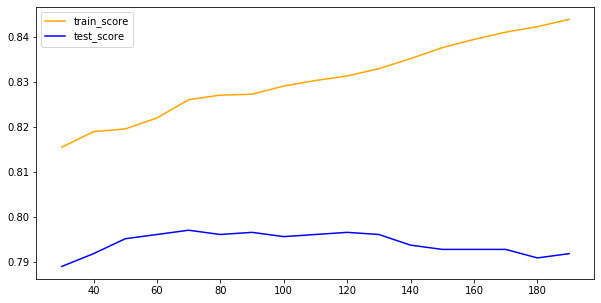

In [53]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(n_estimators_range, train_score, color='orange', label='train_score')
ax.plot(n_estimators_range, test_score, color='blue', label='test_score')
plt.legend(loc='best')

In [55]:
from sklearn.model_selection import cross_val_score
cv_score = []
n_estimators_range = np.arange(30,200,10)
for n_estimator in n_estimators_range:
    xgbc = XGBClassifier(n_estimators=n_estimator)
    cv_score.append(cross_val_score(xgbc, X, y, cv=5, n_jobs= -1).mean())

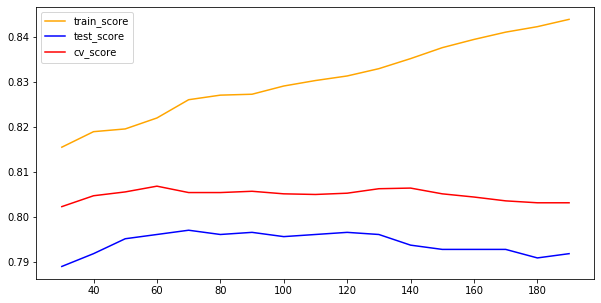

In [56]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(n_estimators_range, train_score, color='orange', label='train_score')
ax.plot(n_estimators_range, test_score, color='blue', label='test_score')
ax.plot(n_estimators_range, cv_score, color='red', label='cv_score')
plt.legend(loc='best')

根据上面绘制的学习曲线，选择n_estimator=70

---
# 集成模型